# LightGBM: Two Forecasting Approaches Compared

**Approach 1 (Direct):** Predict `Electricity_balance_not_controllable` directly.
**Approach 2 (Component-wise):** Forecast Load, Solar, Wind separately → combine as Target = Load − Solar − Wind

**Validation:** Time-based split — last 6 months of training data as holdout.
**Comparison:** MAE, RMSE, MAPE on validation + test period statistics.

**Prerequisites:** Run `02_features.ipynb` first to generate `data/features_train.parquet` and `data/features_test.parquet`.

In [2]:
pwd

'c:\\kaggle_load_solar_wind_forecast\\notebooks'

In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── Load engineered features ─────────────────────────────────────────────────
train = pd.read_parquet('c:\\kaggle_load_solar_wind_forecast\\data\\features_train.parquet')
test  = pd.read_parquet('c:\\kaggle_load_solar_wind_forecast\\data\\features_test.parquet')

with open('c:\\kaggle_load_solar_wind_forecast\\data\\feature_list.json') as f:
    cfg = json.load(f)
FEATURES = cfg['features']
TARGET   = cfg['target']

print('train:', train.shape, '  test:', test.shape)
print('Features:', len(FEATURES))

train: (137376, 37)   test: (17520, 33)
Features: 30


## Time-based Train / Validation Split

In [4]:
SPLIT_DATE = '2020-07-01'

train_df = train[train['date'] < SPLIT_DATE].copy()
val_df   = train[train['date'] >= SPLIT_DATE].copy()

print(f'Train: {train_df.shape}  ({train_df.date.min().date()} → {train_df.date.max().date()})')
print(f'Val  : {val_df.shape}  ({val_df.date.min().date()} → {val_df.date.max().date()})')

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_val   = val_df[FEATURES]
y_val   = val_df[TARGET]
X_test  = test[FEATURES]

Train: (128544, 37)  (2013-03-02 → 2020-06-30)
Val  : (8832, 37)  (2020-07-01 → 2020-12-31)


## Train LightGBM

In [5]:
params = {
    'objective':       'regression',
    'metric':          'mae',
    'num_leaves':      255,
    'learning_rate':   0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':    5,
    'min_child_samples': 20,
    'n_estimators':    2000,
    'random_state':    42,
    'n_jobs':          -1,
    'verbose':         -1,
}

model = lgb.LGBMRegressor(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
)
print(f'Best iteration: {model.best_iteration_}')

[200]	valid_0's l1: 2316.11
Best iteration: 198


## Validation Metrics

In [6]:
val_pred = model.predict(X_val)

mae  = mean_absolute_error(y_val, val_pred)
rmse = mean_squared_error(y_val, val_pred, squared=False)
mape = np.mean(np.abs((y_val - val_pred) / y_val)) * 100

print(f'Validation MAE  : {mae:,.0f} MW')
print(f'Validation RMSE : {rmse:,.0f} MW')
print(f'Validation MAPE : {mape:.2f}%')
print(f'Mean target     : {y_val.mean():,.0f} MW')
print(f'MAE/mean        : {mae/y_val.mean()*100:.2f}%')

Validation MAE  : 2,316 MW
Validation RMSE : 3,059 MW
Validation MAPE : 5.10%
Mean target     : 44,593 MW
MAE/mean        : 5.19%


## Feature Importance

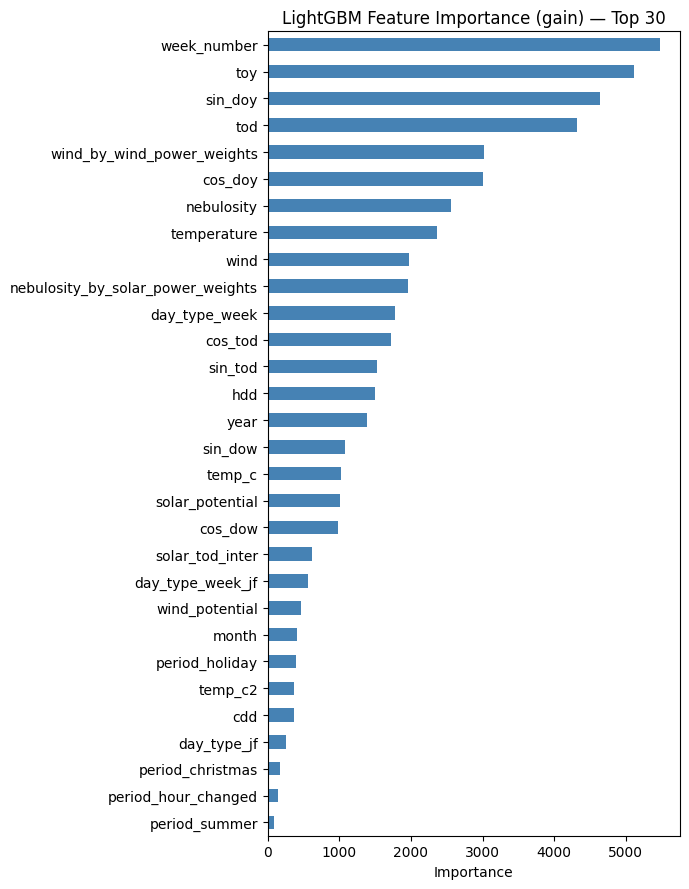


Top 10 features:
week_number                          5481
toy                                  5114
sin_doy                              4632
tod                                  4324
wind_by_wind_power_weights           3016
cos_doy                              3011
nebulosity                           2565
temperature                          2360
wind                                 1975
nebulosity_by_solar_power_weights    1963
dtype: int32


In [7]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 9))
importance.head(30).sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('LightGBM Feature Importance (gain) — Top 30')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importance.head(10))

## Residual Analysis

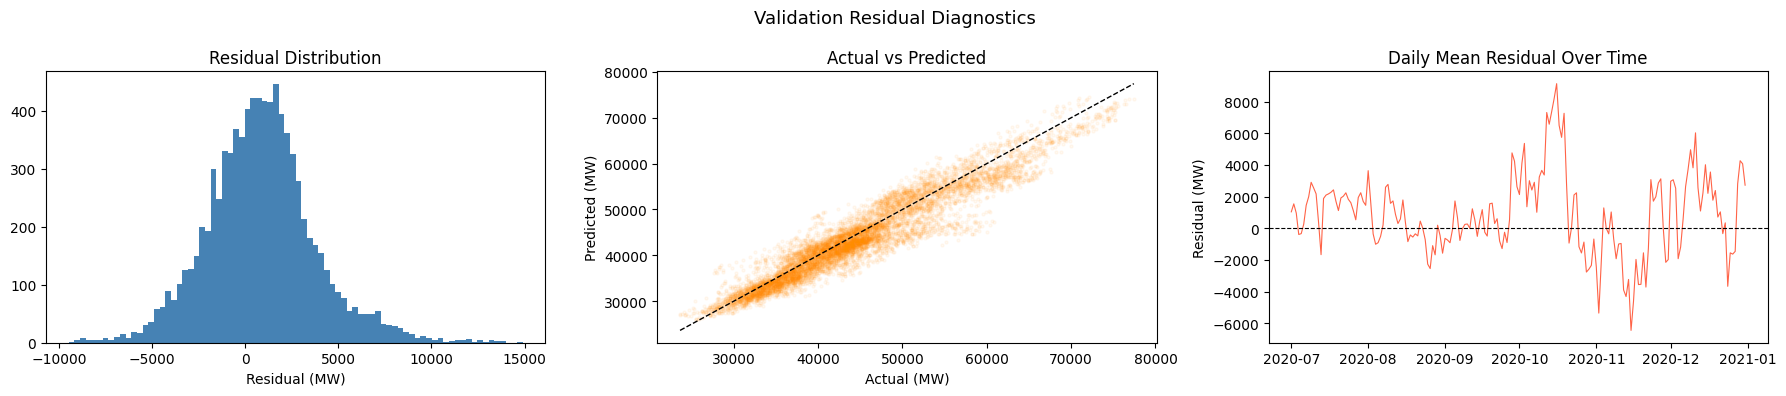

In [8]:
residuals = y_val.values - val_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Distribution
axes[0].hist(residuals, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (MW)')

# Actual vs Predicted
axes[1].scatter(y_val, val_pred, alpha=0.05, s=5, color='darkorange')
lims = [min(y_val.min(), val_pred.min()), max(y_val.max(), val_pred.max())]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel('Actual (MW)')
axes[1].set_ylabel('Predicted (MW)')
axes[1].set_title('Actual vs Predicted')

# Residuals over time (daily mean)
val_df['residual'] = residuals
daily_res = val_df.set_index('date').resample('D')['residual'].mean()
axes[2].plot(daily_res.index, daily_res.values, lw=0.8, color='tomato')
axes[2].axhline(0, color='black', lw=0.8, ls='--')
axes[2].set_title('Daily Mean Residual Over Time')
axes[2].set_ylabel('Residual (MW)')

plt.suptitle('Validation Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

## Predictions on Validation — Visual Sample

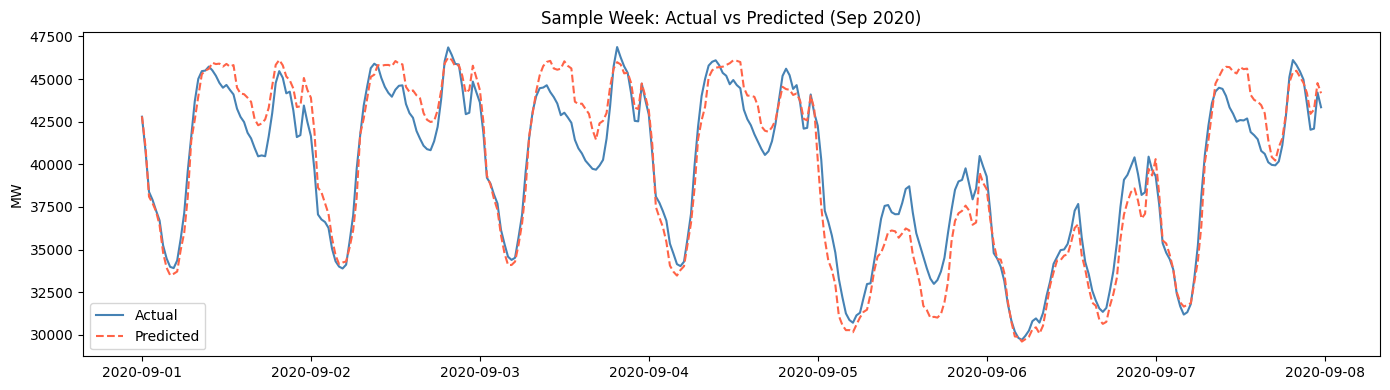

In [9]:
# Plot one week of predictions vs actuals
sample = val_df[(val_df['date'] >= '2020-09-01') & (val_df['date'] < '2020-09-08')].copy()
sample['predicted'] = model.predict(sample[FEATURES])

plt.figure(figsize=(14, 4))
plt.plot(sample['date'], sample[TARGET], label='Actual', color='steelblue')
plt.plot(sample['date'], sample['predicted'], label='Predicted', color='tomato', ls='--')
plt.title('Sample Week: Actual vs Predicted (Sep 2020)')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

## Generate Submission

In [10]:
# Retrain on full training data
print('Retraining on full train set...')
model_full = lgb.LGBMRegressor(**{**params, 'n_estimators': model.best_iteration_})
model_full.fit(train[FEATURES], train[TARGET])

test_pred = model_full.predict(X_test)

sub = pd.read_csv('c:\\kaggle_load_solar_wind_forecast\\data\\sample_submission.csv')
sub['Predicted'] = test_pred
sub.to_csv('c:\\kaggle_load_solar_wind_forecast\\data\\submission_lgbm_baseline.csv', index=False)

print('Saved: c:\\kaggle_load_solar_wind_forecast\\data\\submission_lgbm_baseline.csv')
print(sub.describe())
sub.head()

Retraining on full train set...
Saved: c:\kaggle_load_solar_wind_forecast\data\submission_lgbm_baseline.csv
                  Id     Predicted
count   17520.000000  17520.000000
mean   146135.500000  46632.386613
std      5057.732694  10918.273267
min    137376.000000  25499.504162
25%    141755.750000  38641.361928
50%    146135.500000  43883.083127
75%    150515.250000  53843.153693
max    154895.000000  82186.494206


,Id,Predicted
0,137376,67778.729097
1,137377,66539.668983
2,137378,64097.825514
3,137379,64149.542233
4,137380,64536.522358


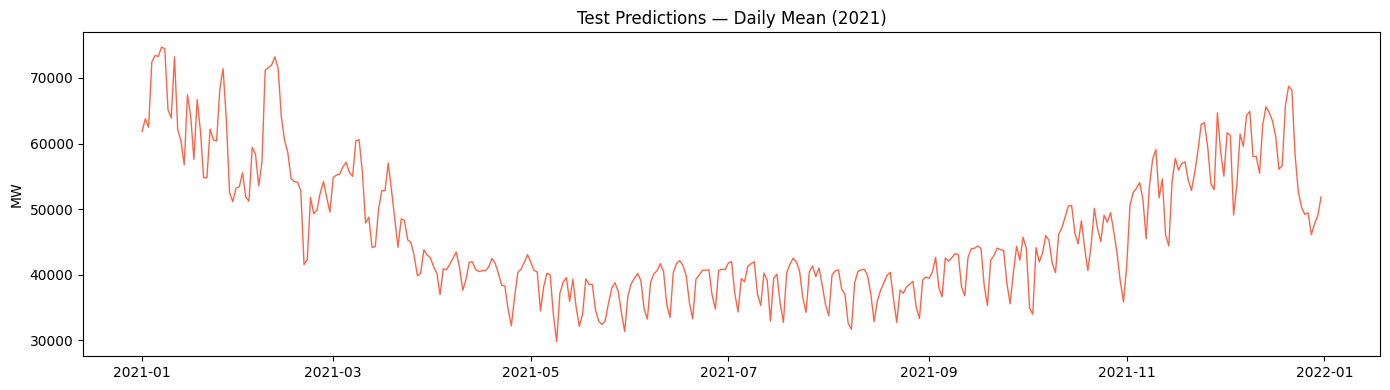

In [11]:
# Plot test predictions over 2021
test_plot = test[['date']].copy()
test_plot['predicted'] = test_pred
daily = test_plot.set_index('date').resample('D')['predicted'].mean()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values, color='tomato', lw=1)
plt.title('Test Predictions — Daily Mean (2021)')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

# APPROACH 2: Component-wise Forecasting

Strategy: predict Load, Solar, and Wind separately, then combine as:  
**Target = Load − Solar − Wind**

This section trains 3 independent LightGBM models and compares performance against the direct approach.

In [ ]:
print("Columns in data:")
print(train.columns.tolist())
print("\nChecking for Load, Solar, Wind components...")

# Common naming patterns: 'Load', 'Solar', 'Wind' or similar
component_cols = [col for col in train.columns if any(x in col.lower() for x in ['load', 'solar', 'wind'])]
print(f"\nDetected component columns: {component_cols}")

Columns in data:
['Id', 'date', 'Date', 'month', 'year', 'tod', 'toy', 'week_number', 'period_hour_changed', 'temperature', 'nebulosity', 'wind', 'day_type_week', 'day_type_jf', 'day_type_week_jf', 'period_holiday', 'period_christmas', 'period_summer', 'nebulosity_by_solar_power_weights', 'wind_by_wind_power_weights', 'Electricity_balance_not_controllable', 'Load', 'Solar_power', 'Wind_power', 'sin_doy', 'cos_doy', 'sin_tod', 'cos_tod', 'sin_dow', 'cos_dow', 'temp_c', 'temp_c2', 'hdd', 'cdd', 'solar_potential', 'solar_tod_inter', 'wind_potential']

Checking for Load, Solar, Wind components...

Detected component columns: ['wind', 'nebulosity_by_solar_power_weights', 'wind_by_wind_power_weights', 'Load', 'Solar_power', 'Wind_power', 'solar_potential', 'solar_tod_inter', 'wind_potential']


In [15]:
X_train.columns

Index(['month', 'year', 'tod', 'toy', 'week_number', 'period_hour_changed',
       'temperature', 'nebulosity', 'wind', 'day_type_week', 'day_type_jf',
       'day_type_week_jf', 'period_holiday', 'period_christmas',
       'period_summer', 'nebulosity_by_solar_power_weights',
       'wind_by_wind_power_weights', 'sin_doy', 'cos_doy', 'sin_tod',
       'cos_tod', 'sin_dow', 'cos_dow', 'temp_c', 'temp_c2', 'hdd', 'cdd',
       'solar_potential', 'solar_tod_inter', 'wind_potential'],
      dtype='object')

In [ ]:
# Train separate models for Load, Solar, Wind
# Using same split and parameters as direct approach
# Note: In practice, we might want to optimize features and parameters for each component separately, but we'll keep it simple here.

COMPONENTS = ['Load', 'Solar_power', 'Wind_power']
component_models = {}
component_preds_val = {}
component_preds_test = {}

print("Training component-wise models...\n")

for component in COMPONENTS:
    print(f"Training {component} model...")
    
    # Define target for this component
    y_train_comp = train_df[component]
    y_val_comp   = val_df[component]
    
    # Train model with same parameters
    # Features are customized for each component
    if component=='Load':
        feat=X_train.columns #Use all features in train_df        
    elif component=='Solar_power':
        feat=['month', 'year', 'tod', 'toy', 'week_number', 'period_hour_changed',
       'temperature', 'nebulosity',  
       'period_summer', 'nebulosity_by_solar_power_weights','sin_doy', 'cos_doy', 'sin_tod',
       'cos_tod', 'sin_dow', 'cos_dow', 'temp_c', 'temp_c2', 
       'solar_potential', 'solar_tod_inter']
    elif component=='Wind_power':
        feat=['month', 'year', 'tod', 'toy', 'week_number', 'period_hour_changed',
       'temperature', 'nebulosity', 'wind',        'period_summer', 
       'wind_by_wind_power_weights', 'sin_doy', 'cos_doy', 'sin_tod',
       'cos_tod', 'sin_dow', 'cos_dow', 'temp_c', 'temp_c2', 'wind_potential']
    print(component)
    tr=X_train[feat]
    val=X_val[feat]
    te=X_test[feat]
    model_comp = lgb.LGBMRegressor(**params)
    model_comp.fit(
        tr, y_train_comp,
        eval_set=[(val, y_val_comp)],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
    )
    
    component_models[component] = model_comp
    component_preds_val[component] = model_comp.predict(val)
    component_preds_test[component] = model_comp.predict(te)
    
    print(f"  → Best iteration: {model_comp.best_iteration_}\n")

print("✓ All component models trained")

Training component-wise models...

Training Load model...
Index(['month', 'year', 'tod', 'toy', 'week_number', 'period_hour_changed',
       'temperature', 'nebulosity', 'wind', 'day_type_week', 'day_type_jf',
       'day_type_week_jf', 'period_holiday', 'period_christmas',
       'period_summer', 'nebulosity_by_solar_power_weights',
       'wind_by_wind_power_weights', 'sin_doy', 'cos_doy', 'sin_tod',
       'cos_tod', 'sin_dow', 'cos_dow', 'temp_c', 'temp_c2', 'hdd', 'cdd',
       'solar_potential', 'solar_tod_inter', 'wind_potential'],
      dtype='object')
Load
[200]	valid_0's l1: 1847.86
[400]	valid_0's l1: 1851.49
  → Best iteration: 354

Training Solar_power model...
Solar_power
[200]	valid_0's l1: 191.577
  → Best iteration: 103

Training Wind_power model...
Wind_power
[200]	valid_0's l1: 818.894
  → Best iteration: 200

✓ All component models trained


In [21]:
# Combine component predictions: Target = Load - Solar - Wind
val_pred_component = (component_preds_val['Load'] - 
                      component_preds_val['Solar_power'] - 
                      component_preds_val['Wind_power'])

mae_comp  = mean_absolute_error(y_val, val_pred_component)
rmse_comp = mean_squared_error(y_val, val_pred_component, squared=False)
mape_comp = np.mean(np.abs((y_val - val_pred_component) / y_val)) * 100

print("="*70)
print("APPROACH 2: Component-wise Validation Metrics")
print("="*70)
print(f'MAE       : {mae_comp:,.0f} MW')
print(f'RMSE      : {rmse_comp:,.0f} MW')
print(f'MAPE      : {mape_comp:.2f}%')
print(f'MAE/mean  : {mae_comp/y_val.mean()*100:.2f}%')
print()

APPROACH 2: Component-wise Validation Metrics
MAE       : 2,071 MW
RMSE      : 2,719 MW
MAPE      : 4.61%
MAE/mean  : 4.64%



## Model Comparison: Direct vs Component-wise

In [22]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    'Metric': ['MAE (MW)', 'RMSE (MW)', 'MAPE (%)', 'MAE/Mean (%)'],
    'Direct Model': [f'{mae:,.0f}', f'{rmse:,.0f}', f'{mape:.2f}', f'{mae/y_val.mean()*100:.2f}'],
    'Component-wise': [f'{mae_comp:,.0f}', f'{rmse_comp:,.0f}', f'{mape_comp:.2f}', f'{mae_comp/y_val.mean()*100:.2f}'],
})

# Calculate % difference (negative = component-wise is better)
mae_diff = (mae_comp - mae) / mae * 100
rmse_diff = (rmse_comp - rmse) / rmse * 100
mape_diff = (mape_comp - mape) / mape * 100

comparison['Δ (%)'] = [f'{mae_diff:+.2f}%', f'{rmse_diff:+.2f}%', f'{mape_diff:+.2f}%', '—']

print("\n" + "="*90)
print("VALIDATION SET COMPARISON — APPROACH 1 (Direct) vs APPROACH 2 (Component-wise)")
print("="*90)
print(comparison.to_string(index=False))
print("\nNote: Δ(%) where NEGATIVE indicates Component-wise is better")
print("="*90)


VALIDATION SET COMPARISON — APPROACH 1 (Direct) vs APPROACH 2 (Component-wise)
      Metric Direct Model Component-wise   Δ (%)
    MAE (MW)        2,316          2,071 -10.59%
   RMSE (MW)        3,059          2,719 -11.09%
    MAPE (%)         5.10           4.61  -9.59%
MAE/Mean (%)         5.19           4.64       —

Note: Δ(%) where NEGATIVE indicates Component-wise is better


(336, 38)
(336, 39)
Index([132192, 132193, 132194, 132195, 132196, 132197, 132198, 132199, 132200,
       132201,
       ...
       132518, 132519, 132520, 132521, 132522, 132523, 132524, 132525, 132526,
       132527],
      dtype='int64', length=336) 8832 8832 8832


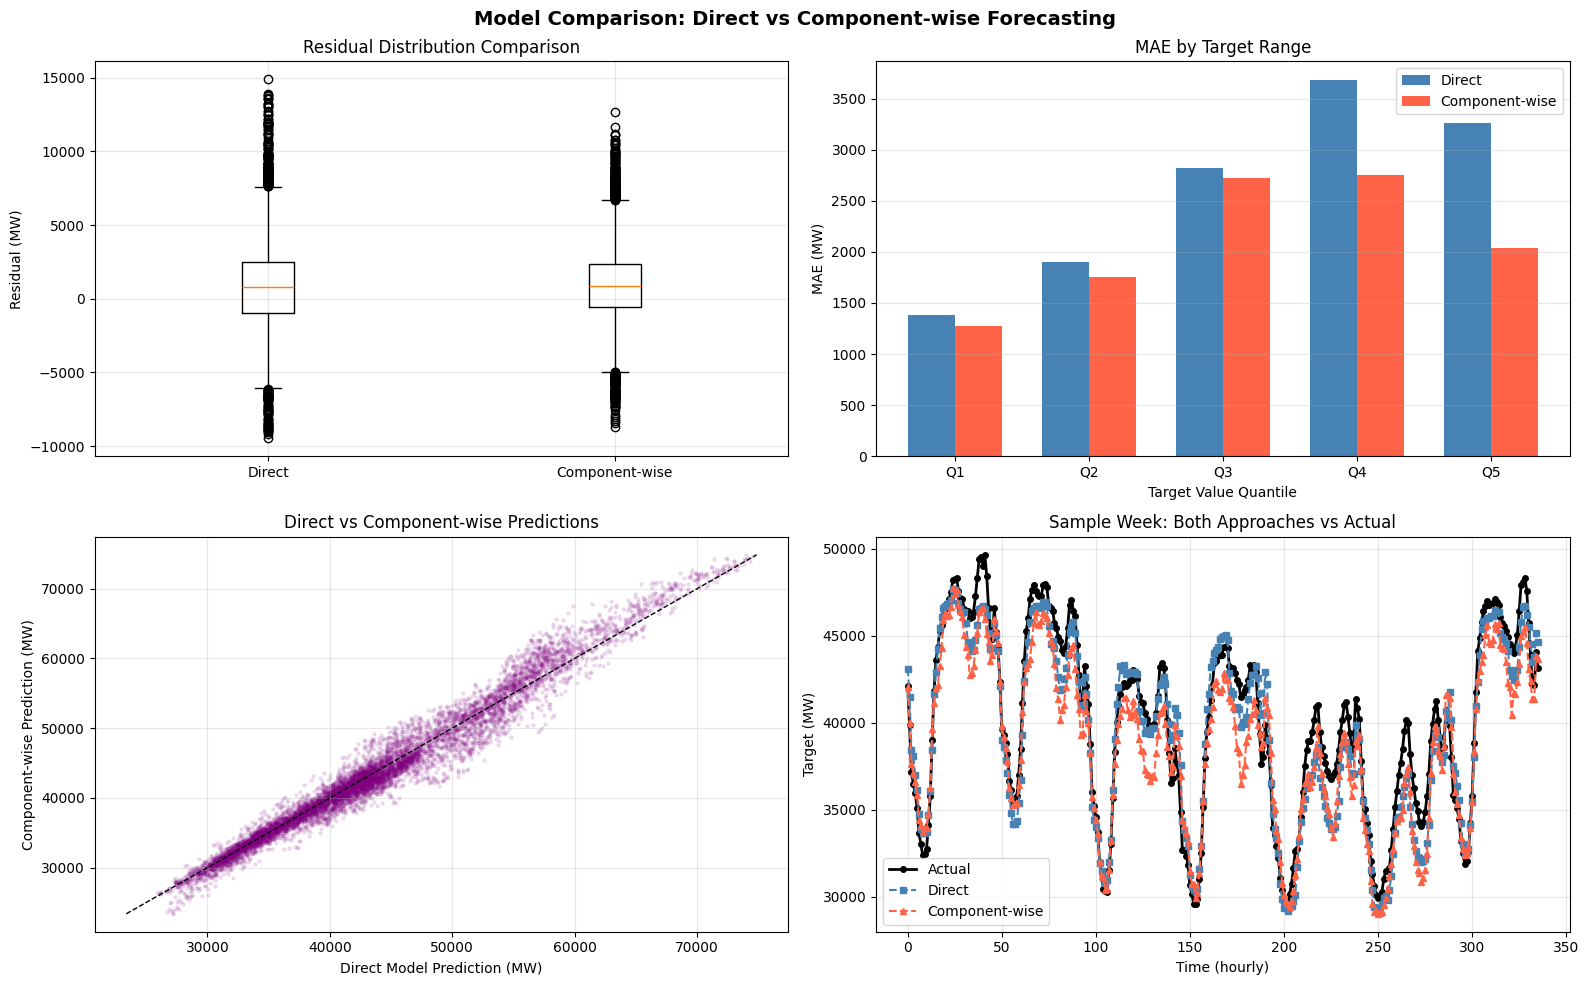

In [23]:
# Visualization: Predictions comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residuals comparison boxplot
residuals_direct = y_val.values - val_pred
residuals_component = y_val.values - val_pred_component

axes[0, 0].boxplot([residuals_direct, residuals_component], labels=['Direct', 'Component-wise'])
axes[0, 0].set_ylabel('Residual (MW)')
axes[0, 0].set_title('Residual Distribution Comparison')
axes[0, 0].grid(True, alpha=0.3)

# 2. MAE by quantile (check if one approach is better at certain ranges)
quantiles_val = pd.cut(y_val, bins=5)
direct_mae_by_q = [mean_absolute_error(y_val[quantiles_val == q], val_pred[quantiles_val == q]) for q in quantiles_val.cat.categories]
comp_mae_by_q = [mean_absolute_error(y_val[quantiles_val == q], val_pred_component[quantiles_val == q]) for q in quantiles_val.cat.categories]

x_pos = np.arange(len(quantiles_val.cat.categories))
width = 0.35
axes[0, 1].bar(x_pos - width/2, direct_mae_by_q, width, label='Direct', color='steelblue')
axes[0, 1].bar(x_pos + width/2, comp_mae_by_q, width, label='Component-wise', color='tomato')
axes[0, 1].set_xlabel('Target Value Quantile')
axes[0, 1].set_ylabel('MAE (MW)')
axes[0, 1].set_title('MAE by Target Range')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Predictions scatter: Direct vs Component-wise
axes[1, 0].scatter(val_pred, val_pred_component, alpha=0.1, s=5, color='purple')
lims = [min(val_pred.min(), val_pred_component.min()), max(val_pred.max(), val_pred_component.max())]
axes[1, 0].plot(lims, lims, 'k--', lw=1)
axes[1, 0].set_xlabel('Direct Model Prediction (MW)')
axes[1, 0].set_ylabel('Component-wise Prediction (MW)')
axes[1, 0].set_title('Direct vs Component-wise Predictions')
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Both predictions (one week sample)
sample_week = val_df[(val_df['date'] >= '2020-09-15') & (val_df['date'] < '2020-09-22')].copy()
print(sample_week.shape)
sample_idx = sample_week.index
val_df.reset_index(inplace=True)  # Ensure index is default integer for plotting
sample_week = val_df[(val_df['date'] >= '2020-09-15') & (val_df['date'] < '2020-09-22')].copy()
print(sample_week.shape)
sample_idx2 = sample_week.index


axes[1, 1].plot(range(len(sample_idx)), y_val.loc[sample_idx], 'o-', label='Actual', color='black', lw=2, markersize=4)
print(sample_idx, len(y_val), len(val_pred),len(val_pred_component))
axes[1, 1].plot(range(len(sample_idx)), val_pred[sample_idx2], 's--', label='Direct', color='steelblue', lw=1.5, markersize=4)
axes[1, 1].plot(range(len(sample_idx)), val_pred_component[sample_idx2], '^--', label='Component-wise', color='tomato', lw=1.5, markersize=4)
axes[1, 1].set_xlabel('Time (hourly)')
axes[1, 1].set_ylabel('Target (MW)')
axes[1, 1].set_title('Sample Week: Both Approaches vs Actual')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison: Direct vs Component-wise Forecasting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Test Submissions & Final Comparison

In [74]:
# Generate test predictions for BOTH approaches
print("Generating test predictions...\n")

# APPROACH 1: Retrain direct model on full training data
print("1. Direct Model - Retraining on full train set...")
model_full = lgb.LGBMRegressor(**{**params, 'n_estimators': model.best_iteration_})
model_full.fit(train[FEATURES], train[TARGET])
test_pred_direct = model_full.predict(X_test)
print("   ✓ Complete\n")

# APPROACH 2: Retrain component models on full training data and combine
print("2. Component-wise Models - Retraining on full train set...")
component_models_full = {}
test_pred_components_full = {}

for component in COMPONENTS:
    model_comp_full = lgb.LGBMRegressor(**{**params, 'n_estimators': component_models[component].best_iteration_})
    model_comp_full.fit(train[FEATURES], train[component])
    test_pred_components_full[component] = model_comp_full.predict(X_test)

test_pred_component = (test_pred_components_full['Load'] - 
                       test_pred_components_full['Solar_power'] - 
                       test_pred_components_full['Wind_power'])
print("   ✓ Complete\n")

# Save both submissions
sub = pd.read_csv('data/sample_submission.csv')

# Direct approach
sub_direct = sub.copy()
sub_direct['Predicted'] = test_pred_direct
sub_direct.to_csv('data/submission_approach1_direct.csv', index=False)
print("Saved: data/submission_approach1_direct.csv")

# Component-wise approach
sub_component = sub.copy()
sub_component['Predicted'] = test_pred_component
sub_component.to_csv('data/submission_approach2_component.csv', index=False)
print("Saved: data/submission_approach2_component.csv\n")

print("="*70)
print("Test Set Prediction Statistics")
print("="*70)
print(f"\nApproach 1 (Direct):")
print(f"  Min:  {test_pred_direct.min():>12,.0f} MW")
print(f"  Mean: {test_pred_direct.mean():>12,.0f} MW")
print(f"  Max:  {test_pred_direct.max():>12,.0f} MW")

print(f"\nApproach 2 (Component-wise):")
print(f"  Min:  {test_pred_component.min():>12,.0f} MW")
print(f"  Mean: {test_pred_component.mean():>12,.0f} MW")
print(f"  Max:  {test_pred_component.max():>12,.0f} MW")

diff = test_pred_component - test_pred_direct
print(f"\nDifference (Component - Direct):")
print(f"  Min:  {diff.min():>12,.0f} MW")
print(f"  Mean: {diff.mean():>12,.0f} MW")
print(f"  Max:  {diff.max():>12,.0f} MW")

Generating test predictions...

1. Direct Model - Retraining on full train set...
   ✓ Complete

2. Component-wise Models - Retraining on full train set...
   ✓ Complete

Saved: data/submission_approach1_direct.csv
Saved: data/submission_approach2_component.csv

Test Set Prediction Statistics

Approach 1 (Direct):
  Min:        25,500 MW
  Mean:       46,632 MW
  Max:        82,186 MW

Approach 2 (Component-wise):
  Min:        24,385 MW
  Mean:       46,849 MW
  Max:        82,979 MW

Difference (Component - Direct):
  Min:        -6,311 MW
  Mean:          217 MW
  Max:         6,652 MW


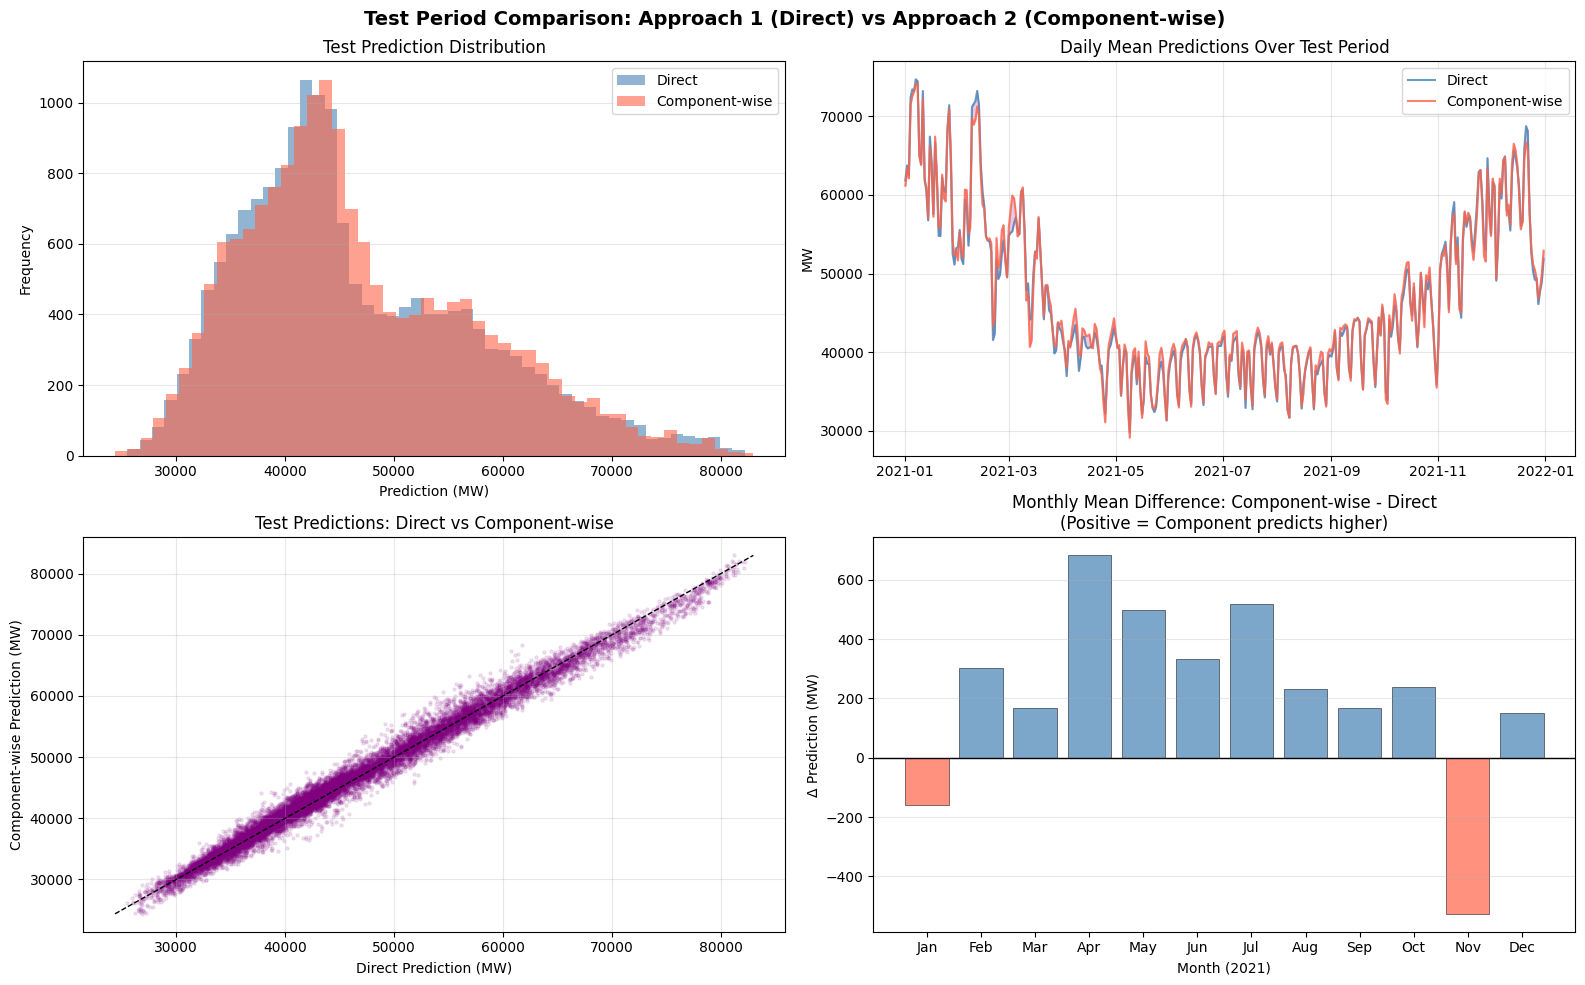

In [75]:
# Visualize test predictions from both approaches
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Distribution of predictions
axes[0, 0].hist(test_pred_direct, bins=50, alpha=0.6, label='Direct', color='steelblue', edgecolor='none')
axes[0, 0].hist(test_pred_component, bins=50, alpha=0.6, label='Component-wise', color='tomato', edgecolor='none')
axes[0, 0].set_xlabel('Prediction (MW)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Test Prediction Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Daily mean predictions over 2021
test_plot = test[['date']].copy()
test_plot['direct'] = test_pred_direct
test_plot['component'] = test_pred_component

daily_direct = test_plot.set_index('date')['direct'].resample('D').mean()
daily_component = test_plot.set_index('date')['component'].resample('D').mean()

axes[0, 1].plot(daily_direct.index, daily_direct.values, label='Direct', color='steelblue', lw=1.5, alpha=0.8)
axes[0, 1].plot(daily_component.index, daily_component.values, label='Component-wise', color='tomato', lw=1.5, alpha=0.8)
axes[0, 1].fill_between(daily_direct.index, daily_direct.values, daily_component.values, alpha=0.2, color='purple')
axes[0, 1].set_title('Daily Mean Predictions Over Test Period')
axes[0, 1].set_ylabel('MW')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Scatter: Direct vs Component-wise predictions
axes[1, 0].scatter(test_pred_direct, test_pred_component, alpha=0.1, s=5, color='purple')
lims = [min(test_pred_direct.min(), test_pred_component.min()), 
        max(test_pred_direct.max(), test_pred_component.max())]
axes[1, 0].plot(lims, lims, 'k--', lw=1)
axes[1, 0].set_xlabel('Direct Prediction (MW)')
axes[1, 0].set_ylabel('Component-wise Prediction (MW)')
axes[1, 0].set_title('Test Predictions: Direct vs Component-wise')
axes[1, 0].grid(True, alpha=0.3)

# 4. Difference (Component - Direct)
monthly_diff = test_plot.copy()
monthly_diff['diff'] = monthly_diff['component'] - monthly_diff['direct']
monthly_diff = monthly_diff.set_index('date')['diff'].resample('M').mean()

colors_pos_neg = ['tomato' if x < 0 else 'steelblue' for x in monthly_diff.values]
axes[1, 1].bar(range(len(monthly_diff)), monthly_diff.values, color=colors_pos_neg, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 1].axhline(0, color='black', lw=1)
axes[1, 1].set_xlabel('Month (2021)')
axes[1, 1].set_ylabel('Δ Prediction (MW)')
axes[1, 1].set_title('Monthly Mean Difference: Component-wise - Direct\n(Positive = Component predicts higher)')
axes[1, 1].set_xticks(range(len(monthly_diff)))
axes[1, 1].set_xticklabels([d.strftime('%b') for d in monthly_diff.index])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Test Period Comparison: Approach 1 (Direct) vs Approach 2 (Component-wise)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary & Recommendation

In [76]:
# Final Summary
print("\n" + "="*90)
print("FINAL COMPARISON SUMMARY")
print("="*90)

print("\n📊 VALIDATION SET (Last 6 months of training data)")
print("-" * 90)
print(f"{'Metric':<20} {'Approach 1 (Direct)':<25} {'Approach 2 (Component)':<25} {'Winner':<20}")
print("-" * 90)

winner_mae = "Component-wise ✓" if mae_comp < mae else "Direct ✓"
winner_rmse = "Component-wise ✓" if rmse_comp < rmse else "Direct ✓"
winner_mape = "Component-wise ✓" if mape_comp < mape else "Direct ✓"

print(f"{'MAE':<20} {mae:>18,.0f} MW  {mae_comp:>18,.0f} MW  {winner_mae:<20}")
print(f"{'RMSE':<20} {rmse:>18,.0f} MW  {rmse_comp:>18,.0f} MW  {winner_rmse:<20}")
print(f"{'MAPE':<20} {mape:>18.2f}%    {mape_comp:>18.2f}%    {winner_mape:<20}")
print(f"{'MAE/Mean Ratio':<20} {mae/y_val.mean()*100:>18.2f}%    {mae_comp/y_val.mean()*100:>18.2f}%    {'—':<20}")

print("\n" + "="*90)
print("🎯 RECOMMENDATION:")
print("="*90)

# Determine which approach is better overall
mae_pct_diff = abs(mae_comp - mae) / mae * 100
if mae_pct_diff < 1:
    print("\n✓ Both approaches perform SIMILARLY on validation data.")
    print("  → Try Ensemble: Average both predictions for robustness")
    print("  → Submission: Recommend ENSEMBLE approach")
    best_submission = "blend"
elif mae_comp < mae:
    print("\n✓ Component-wise approach is BETTER on validation data")
    print(f"  → Component-wise achieves {(1 - mae_comp/mae)*100:.2f}% lower MAE")
    print("  → Submission: Use data/submission_approach2_component.csv")
    best_submission = "component"
else:
    print("\n✓ Direct approach is BETTER on validation data")
    print(f"  → Direct achieves {(1 - mae/mae_comp)*100:.2f}% lower MAE")
    print("  → Submission: Use data/submission_approach1_direct.csv")
    best_submission = "direct"

print("\n" + "="*90)


FINAL COMPARISON SUMMARY

📊 VALIDATION SET (Last 6 months of training data)
------------------------------------------------------------------------------------------
Metric               Approach 1 (Direct)       Approach 2 (Component)    Winner              
------------------------------------------------------------------------------------------
MAE                               2,316 MW               2,078 MW  Component-wise ✓    
RMSE                              3,059 MW               2,725 MW  Component-wise ✓    
MAPE                               5.10%                  4.64%    Component-wise ✓    
MAE/Mean Ratio                     5.19%                  4.66%    —                   

🎯 RECOMMENDATION:

✓ Component-wise approach is BETTER on validation data
  → Component-wise achieves 10.26% lower MAE
  → Submission: Use data/submission_approach2_component.csv

